# Funciones: nivel avanzado.  {#sec-v-funciones-avanzado}

**Objetivo.**
Revisar conceptos avanzados de funciones en Python como argumentos por omisión, posicionales, con nombre, funciones que reciben y regresan funciones, ámbitos entre otros.

## Argumentos por omisión.

Los parámetros de una función pueden tener valores (argumentos) por omisión, es decir, si no se da un valor para uno de los parámetros, entonces se toma el valor definido por omisión. Esto crea una función que se puede llamar con menos argumentos de los que está definida inicialmente. 

::: {#exm-v-1 .callout-tip icon=false}
## {{< iconify vscode-icons:file-type-light-mypy >}} Tiro vertical.

El tiro vertical hacia arriba se calcula usando la siguiente fórmula:

$$
\begin{eqnarray}
\text{Posición: } \; y & = & v_0 t - \dfrac{g t^2}{2} \tag{1}\\
\text{Velocidad: } \; v_f & = & v_0 - g t \tag{2}
\end{eqnarray}
$$

donde $t$ es el tiempo que ha pasado desde el lanzamiento inicial, $g = 9.81 \text{ [m/s}^2\text{]}$ es la aceleración de la gravedad, $v_0$ es la velocidad inicial y $v_f$ es la velocidad del objeto al tiempo $t$.


Escribir la función `tiroVertical(t, v0)`, que recibe como parámetros el tiempo `t` y la velocidad inicial `v0`, esta última con un valor por omisión de $20 \text{ [m/s]}$.

:::

In [1]:
def tiroVertical(t, v0 = 20):  # Valor por omisión para v0
    g = 9.81                    # Aceleración de la gravedad [m/s^2]
    y = v0 * t - 0.5 * g * t**2 # Posición
    v = v0 - g * t              # Velocidad
    return (y, v)               # Regresa la posición [m] y la velocidad [m/s]

In [2]:
pos, vel = tiroVertical(1.0) # El valor 1.0 corresponde al primer parámetro de la función, 't'
                             # En este caso v0 será igual a 20.

print("{:>10s} = {:>5.2f} [m]".format("Posición", pos))
print("{:>10s} = {:>5.2f} [m/s]".format("Velocidad", vel))

  Posición = 15.09 [m]
 Velocidad = 10.19 [m/s]


In [3]:
pos, vel = tiroVertical(1.0, 30) # En este caso v0 = 30

print("{:>10s} = {:>5.2f} [m]".format("Posición", pos))
print("{:>10s} = {:>5.2f} [m/s]".format("Velocidad", vel))

  Posición = 25.09 [m]
 Velocidad = 20.19 [m/s]



Una función puede tener más de un argumento por omisión. Todos los parámetros que tienen argumentos por omisión deben estar al final de la lista en la declaración de la función.

Por ejemplo, una función con cinco parámetros, con los dos últimos con valores por omisión se define como sigue:

In [4]:
def f(a, b, c, d=10, e=20):
    return a+b+c+d+e

In [5]:
print(f(1,2,3))  # Se usan los dos argumentos por omisión 10 y 20

36


In [6]:
print(f(1,2,3,4)) # Se usa el último argumento por omisión 20

30


In [7]:
print(f(1,2,3,4,5)) # Se dan todos los argumentos.

15


## Argumentos posicionales y con nombre.
Un **argumento** es el valor que se le pasa a una función cuando se llama. Hay dos tipos de argumentos:

***Argumento posicional (positional)*** :

1. Un argumento que no es precedido por un identificador: `tiroVertical(3, 50)`
    
2. Un argumento que es pasado en una tupla precedido por `*`: `tiroVertical(*(3, 50))`.

  En este caso, el `*` indica a Python que la tupla `(3, 50)` debe desempacarse cuando se reciba en la función, de tal manera que `3` será el primer argumento y `5` el segundo.


In [8]:
# Los argumentos se sustituyen en los parámetros 
# en el orden de acuerdo con su posición.
tiroVertical(3,50)

(105.85499999999999, 20.57)

In [9]:
# Se pueden pasar los argumentos empacados en una tupla
tiroVertical(*(3,50))

(105.85499999999999, 20.57)

In [10]:
# Ojo, no se puede cambiar el orden los argumentos porque se obtiene un resultado incorrecto.
tiroVertical(50,3)

(-12112.5, -487.5)

***Argumento con nombre (keyword)*** :

3. Un argumento precedido por un identificador. `tiroVertical(t=3, v0=50)`
    
4. Un argumento que se pasa en un diccionario precedido por `**`:`tiroVertical(**{'t': 3, 'v0': 50})`.

  En este caso, el `**` indica a Python que el diccionario `{'t': 3, 'v0': 50}` debe desempacarse cuando se reciba en la función. Observa que el diccionario contiene dos pares clave-valor: `'t': 3` y `'v0': 50`. 

Veamos los ejemplos en código:

Primer recordemos que la firma de la función es `def tiroVertical(t, v0 = 20):` es decir, el primer parámetro es `t` y el segundo es `v0`.

In [11]:
# Se puede usar el nombre del parámetro para determinar
# como se sustituyen los argumentos:
tiroVertical(t=3, v0=50)

(105.85499999999999, 20.57)

In [12]:
# Lo anterior es equivalente a (aquí si se puede cambiar el orden de los argumentos): 
tiroVertical(v0=50, t=3)

(105.85499999999999, 20.57)

In [13]:
# Se pueden pasar los argumentos empacados en un diccionario
tiroVertical(**{'t':3,'v0':50})

(105.85499999999999, 20.57)

In [14]:
# También se acepta esta forma:
tiroVertical(**dict(t = 3,v0 = 50))

(105.85499999999999, 20.57)

## Número variable de parámetros

Dada la funcionalidad descrita en la sección anterior, es posible que una función reciba un número variable de argumentos. Estos argumentos se pueden definir de la siguiente manera

* `*args`: número variable de argumentos posicionales empacados en una tupla
* `*kwargs`: número variable de argumentos con nombre empacados en un diccionario

Por ejemplo:

In [15]:
def parVar(*args, **kwargs):
    print('args es una tupla : ', args)
    print('kwargs es un diccionario: ', kwargs)

In [16]:
parVar('one', 'two','three', 'four', 
       a=4,  x=1, y=2, z=3, w=[1,2,2])

args es una tupla :  ('one', 'two', 'three', 'four')
kwargs es un diccionario:  {'a': 4, 'x': 1, 'y': 2, 'z': 3, 'w': [1, 2, 2]}


In [17]:
parVar(1, 2, 3, w=8, y='cadena')

args es una tupla :  (1, 2, 3)
kwargs es un diccionario:  {'w': 8, 'y': 'cadena'}


Estos argumentos los podemos desempacar y usar dentro de la función:

In [18]:
# Desempacar los parámetros posicionales y usarlos
def parVarPos(*args):
    for i in args:
        print(i)

In [19]:
parVarPos(1, 2, 'a', [1,2,3])

1
2
a
[1, 2, 3]


In [20]:
parVarPos(3.1416, 'b', 5+3j)

3.1416
b
(5+3j)


In [21]:
# Desempacar los parámetros con nombre y usarlos
def parVarKey(**kwargs):
    for key, val in kwargs.items():
        print(f" {key} : {val}")

In [22]:
parVarKey(nombre = 'Luis', 
          apellido = 'de la Cruz', 
          edad = 15, 
          peso = 80.5 )

 nombre : Luis
 apellido : de la Cruz
 edad : 15
 peso : 80.5


In [23]:
parVarKey(nombre = 'Luis', 
          apellido='de la Cruz', 
          estudios='primaria', 
          edad=15, 
          peso=80.5, 
          num_cuenta = 12334457 )

 nombre : Luis
 apellido : de la Cruz
 estudios : primaria
 edad : 15
 peso : 80.5
 num_cuenta : 12334457


In [24]:
# Se pueden definir los parámetros en una tupla y en un diccionario
mi_tupla = (2.345, "hola", 1e-4)
mi_dicc = {'nombre':'Luis', 
           'apellido':'de la Cruz', 
           'edad':15, 
           'peso':80.5}

In [25]:
# Se usa el diccionario para llamar a la función
parVarPos(*mi_tupla)

2.345
hola
0.0001


In [26]:
parVarKey(**mi_dicc)

 nombre : Luis
 apellido : de la Cruz
 edad : 15
 peso : 80.5


## Funciones como parámetros de otras funciones.

Las funciones pueden recibir como argumentos objetos muy complejos, incluso otras funciones. Veamos un ejemplo simple:

In [27]:
# Un función simple
def g():
    print("Iniciando la función 'g()'")

# Una función que recibe otra función:
def func1(f):
    print("Iniciando la función 'func1()'")
    print("Ejecución de la función 'f()', nombre real '" + f.__name__ + "()'")
    f() # Se ejecuta la función que se recibió en el parámetro f

In [28]:
func1(g)

Iniciando la función 'func1()'
Ejecución de la función 'f()', nombre real 'g()'
Iniciando la función 'g()'


La función que se recibe como parámetro puede tener argumentos:

In [29]:
# Función que suma dos números
def suma(a, b):
    return a + b

# Función que resta dos números
def resta(a, b):
    return a - b

# Una función que recibe otra función y dos parámetros adicionales
def func2(f, a, b):
    print("Iniciando la función 'func2()'")
    print(f"Operador: {f.__name__}")
    print(f"Argumentos: ({a}, {b})")
    print(f"Resultado: {f(a,b)}") 

In [30]:
func2(suma, 3, 4)

Iniciando la función 'func2()'
Operador: suma
Argumentos: (3, 4)
Resultado: 7


In [31]:
func2(resta, 6, 7)

Iniciando la función 'func2()'
Operador: resta
Argumentos: (6, 7)
Resultado: -1


.

::: {#exm-v-2 .callout-tip icon=false}
## {{< iconify vscode-icons:file-type-light-mypy >}} Integración.

En este ejemplo el objetivo es crear un función que reciba como argumentos la funcióm matemática a integrar, los límites de integración y el número de puntos para realizar la integración. Debe regresar como resultado un número que es la aproximación de la integral.

:::

In [32]:
import math

def integra(f, a, b, N):
    # Se utiliza el método de Simpson para la integración.
    # El parámetro 'f' es la función a integrar
    print(f"Integral de la función '{f.__name__}()'")
    print(f"Límites de integración: [{a},{b}]")
    print(f"Aproximación con el método de Simpson usando {N} puntos")

    # Implementación del método de integración
    h = (b - a) / N
    resultado = 0
    x = [a + h*i for i in range(N+1)]
    for xi in x:
        resultado += f(xi) * h

    return resultado

In [33]:
# Integral de la función sin() de la biblioteca math.
print("Resultado :", integra(math.sin, 0, math.pi, 100))

Integral de la función 'sin()'
Límites de integración: [0,3.141592653589793]
Aproximación con el método de Simpson usando 100 puntos
Resultado : 1.9998355038874436


In [34]:
# Integral de la función cos() de la biblioteca math.
res = integra(math.cos, -0.5 * math.pi, 0.5 * math.pi, 50)
print(f"Resultado: {res}")

Integral de la función 'cos()'
Límites de integración: [-1.5707963267948966,1.5707963267948966]
Aproximación con el método de Simpson usando 50 puntos
Resultado: 1.9993419830762613


## Funciones que regresan otra función.

Como vimos antes, una función puede regresar un objeto de cualquier tipo, incluyendo una función. Veamos un ejemplo:

In [35]:
# La funcionPadre() regresa como resultado una función 
# la cual está definida dentro de funcionPadre().
def funcionPadre(n):

    # Se define la función 1
    def funcionHijo1():
        return "funcionHijo1(): n = {}".format(n)

    # Se define la función 2
    def funcionHijo2():
        return "funcionHijo2(): n = {}".format(n)

    # Se determina la función que se va a regresar
    if n == 10:
        return funcionHijo1
    else:
        return funcionHijo2

In [36]:
funcionPadre(36)

<function __main__.funcionPadre.<locals>.funcionHijo2()>

In [37]:
# Asignamos el resultado de la funcion_padre() a un nombre
f1 = funcionPadre(10)
f2 = funcionPadre(36)

In [38]:
print(f1()) # Resultado de la funcionf1(), generada con la funcionPadre()
print(f2()) # Resultado de la funcionf2(), generada con la funcionPadre()

funcionHijo1(): n = 10
funcionHijo2(): n = 36


.

::: {#exm-v-3 .callout-tip icon=false}
## {{< iconify vscode-icons:file-type-light-mypy >}} Polinomios.

Implementar una fábrica de polinomios de segundo grado: 

$$
p(x) = a x^2 + b x + c
$$

Verificar el funcionamiento para los polinomios: 
* $p_1(x) = 2x^2 + 3x - 1$.
* $p_2(x) = -x^2 + 2x + 1$.
:::

In [39]:
def polinomio(a, b, c):
    """
    Esta función recibe los coeficientes del polinomio
    y regresa una función que calcula el polinomio de
    segundo grado.
    """
    def segundoGrado(x):
        """
        Calcula el polinomio de segundo grado para el valor de x
        """
        return a * x**2 + b * x + c
    
    return segundoGrado

In [40]:
p1 = polinomio(5, -3, 4)

print(p1(5.6))

144.0


In [41]:
# Dos polinomios de segundo grado
p1 = polinomio(2, 3, -1) # 2x^2 + 3x - 1
p2 = polinomio(-1, 2, 1) # -x^2 + 2x + 1

# Evaluación de los polinomios en el intervalo (-2,2) con pasos de 1
for x in range(-2, 2, 1):
    print(f'x = {x:3d} \t p1(x) = {p1(x):3d} \t p2(x) = {p2(x):3d}')

x =  -2 	 p1(x) =   1 	 p2(x) =  -7
x =  -1 	 p1(x) =  -2 	 p2(x) =  -2
x =   0 	 p1(x) =  -1 	 p2(x) =   1
x =   1 	 p1(x) =   4 	 p2(x) =   2


.

::: {#exm-v-4 .callout-tip icon=false}
## {{< iconify vscode-icons:file-type-light-mypy >}} Gráfica de polinomios

Graficar polinomios de segundo grado generados en el ejemplo anterior en el intervalo $[-10, 10]$.

:::

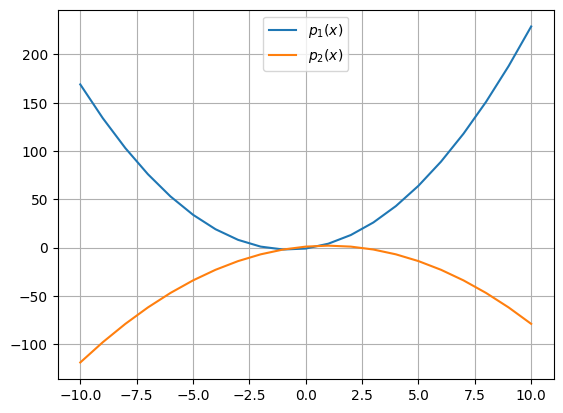

In [42]:
x = []
p1_v = []
p2_v = []
for xi in range(-10, 11):
    x.append(xi)
    p1_v.append(p1(xi))
    p2_v.append(p2(xi))

import matplotlib.pyplot as plt
plt.plot(x, p1_v, label="$p_1(x)$")
plt.plot(x, p2_v, label="$p_2(x)$")
plt.grid()
plt.legend(loc="upper center")
plt.show()

::: {#exm-v-5 .callout-tip icon=false}
## {{< iconify vscode-icons:file-type-light-mypy >}} Polinomios de cualquier grado.

Implementar una fábrica de polinomios de cualquier grado: 

$$
\sum\limits_{k=0}^{n} a_k x^k = a_n x^n + a_{n-1} x^{n-1} + \dots + a_1 x + a_0 
$$

Probar con los siguientes polinomios:
* $p_0(x) = 5$
* $p_1(x) = 4 x + 2$
* $p_2(x) = x^2 + 2x - 1$
* $p_3(x) = x^3 - x^2 + 3x$

Graficar los polinomios como en el ejemplo 9.

:::

In [49]:
def polFactory(*coeficientes):
    """
    Esta función construye y evalúa polinomios 
    de cualquier grado.

    Parameters
    ----------
    *coeficientes: coeficientes del polinomio a_n, a_{n-1}, ..., a_0
    para construir el polinomio.

    Return
    ------
    Función que implementa el polinomio.
    """
    
    def polinomio(x):
        """
        Función que implementa el polinomio y lo evalúa.

        Parameters
        ----------
        x: valor para evaluar el polinomio.

        Return
        ------
        Resultado de evaluación del polinomio en 'x'
        """
        res = 0
        for i, coef in enumerate(coeficientes):
            res += coef * x ** i
        return res
    
    return polinomio

In [50]:
p1 = polFactory(5)
p2 = polFactory(1,2,3,4)

print(p1(3.1416))
print(p2(-3.1416))

5.0
-99.700225117184


In [51]:
# Se generan 4 polinomios de diferente grado
p0 = polFactory(5)           # 5.0
p1 = polFactory(2, 4)        # 4 x + 2
p2 = polFactory(-1, 2, 1)    # x^2 + 2x - 1
p3 = polFactory(0, 3, -1, 1) # x^3 - x^2 + 3x + 0

# Evaluación de los polinomios en el intervalo (-2,2) con pasos de 1
for x in range(-2, 2):
    print(f'x = {x:3d} \t p0(x) = {p0(x):3d} \t p1(x) = {p1(x):3d} \t p2(x) = {p2(x):3d} \t p3(x) = {p3(x):3d}')

x =  -2 	 p0(x) =   5 	 p1(x) =  -6 	 p2(x) =  -1 	 p3(x) = -18
x =  -1 	 p0(x) =   5 	 p1(x) =  -2 	 p2(x) =  -2 	 p3(x) =  -5
x =   0 	 p0(x) =   5 	 p1(x) =   2 	 p2(x) =  -1 	 p3(x) =   0
x =   1 	 p0(x) =   5 	 p1(x) =   6 	 p2(x) =   2 	 p3(x) =   3


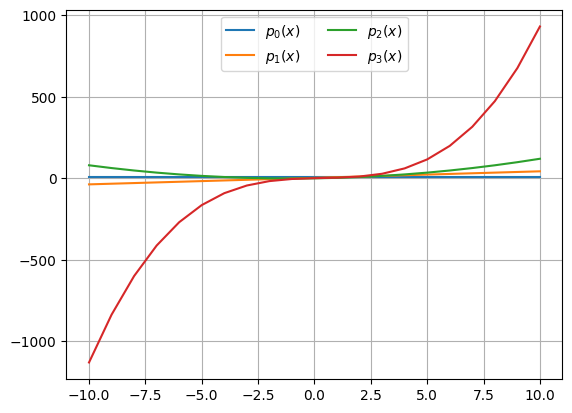

In [52]:
# Graficación
x = []
p0_v = []
p1_v = []
p2_v = []
p3_v = []

for xi in range(-10, 11):
    x.append(xi)
    p0_v.append(p0(xi))
    p1_v.append(p1(xi))
    p2_v.append(p2(xi))
    p3_v.append(p3(xi))

plt.plot(x, p0_v, label="$p_0(x)$")
plt.plot(x, p1_v, label="$p_1(x)$")
plt.plot(x, p2_v, label="$p_2(x)$")
plt.plot(x, p3_v, label="$p_3(x)$")
#plt.ylim(-200,200)
plt.grid()
plt.legend(loc="upper center", ncol=2)
plt.show()

## Ámbitos

Algunos lenguajes como Python usan ámbitos (en algunos casos denominado alcance) para definir variables (aunque también funciones y clases) de tal manera que solo se puedan acceder desde cierto lugar y no desde todas las ubicaciones de un programa. 

En este caso, la capacidad para acceder a un nombre (de variable, función o clase) dependerá de dónde se haya definido ese nombre.

### Local
Las funciones (y otros operadores también), crean su propio ámbito local (*scope*).

In [53]:
def actualizaEdad():
    edad = 21 # Variable local
    print("Ámbito de la función 'actualizaEdad()'")
    print("edad =", edad, ", id(edad) =", id(edad))

# Ejecuto la función
actualizaEdad()

Ámbito de la función 'actualizaEdad()'
edad = 21 , id(edad) = 140714900203048


In [54]:
# ¿Se puede acceder al valor de 'edad' fuera de la función?
print("Ámbito global: edad =", edad, ", id(edad) =", id(edad))

NameError: name 'edad' is not defined

Se obtiene un error, pues `edad` solo está definida dentro del ámbito local de la función `actualizaEdad()`.


### Global

El ámbito global es el alcance más alto en un programa, script o módulo de Python. Este ámbito de Python contiene todos los nombres que se definen en el nivel superior de un programa o módulo. 

Los nombres en este ámbito son visibles desde cualquier lugar del programa.


In [55]:
# Variable creada en el ámbito global
edad = 25

In [56]:
print("Ámbito global: edad =", edad, ", id(edad) =", id(edad))

Ámbito global: edad = 25 , id(edad) = 140714900203176


¿Qué pasa si ejectuamos nuevamente la función `actualizaEdad()`?

In [57]:
actualizaEdad()

Ámbito de la función 'actualizaEdad()'
edad = 21 , id(edad) = 140714900203048


Observa que se usa la variable edad definida dentro de la función y es diferente a la variable `edad` definida en el ámbito global.

Supongamos que deseamos incrementar el valor de la variable global `edad` dentro de la función `actualizaEdad()` como sigue:

In [58]:
edad = 25

def actualizaEdad():
    edad += 1
    return edad

actualizaEdad()

UnboundLocalError: cannot access local variable 'edad' where it is not associated with a value

Observa que se genera un error de tipo `UnboundLocalError` porque se está intentando acceder a un nombre que aún no está definido en el ámbito local de la función.

Entonces, para hacer referencia a la variable global `edad` y modificarla dentro de la función, debes usar la declaración `global`:

In [59]:
edad = 25

def actualizaEdad():
    global edad
    edad += 1
    return edad

actualizaEdad()

26

Aunque lo anterior funciona correctamente, no es recomendable usar esta solución, pues puede tener efectos no deseables. 

Una mejor solución sería la siguiente:

In [60]:
edad = 25

def actualizaEdad(e):
    return e + 1

edad = actualizaEdad(edad)

print(edad)

26


### Enclosing (*nonlocal*) 

El ámbito *enclosing* es un alcance especial que solo existe para funciones anidadas. 

In [61]:
def datosPersonales():
    edad = 25

    def actualizaEdad():
        print(edad)

    actualizaEdad()

datosPersonales()

25


Es posible acceder a las variables definidas en el ámbito de la función `datosPersonales()` (*Enclosing scope*) desde funciones internas o anidadas como `actualizaEdad()`.

Pero no es posible modificar las variables, checa el siguiente código:

In [62]:
def datosPersonales():
    edad = 25

    def actualizaEdad():
        edad += 1
        return edad

    actualizaEdad()

    return edad

datosPersonales()

UnboundLocalError: cannot access local variable 'edad' where it is not associated with a value

Observa que se obtiene otro error de tipo `UnboundLocalError`, pues estamos intentando actualizar la variable `edad` definida en el ámbito de la función `datosPersonales()`. 

Para resolver este problema podemos usar la declaración `nonlocal`:

In [63]:
def datosPersonales():
    edad = 25

    def actualizaEdad():
        nonlocal edad
        edad += 1
        return edad

    actualizaEdad()

    return edad

datosPersonales()

26

### Built-in

Es un ámbito especial de Python que se crea cada vez que se ejecuta un código o se abre una sesión interactiva. 

Este ámbito contiene nombres como palabras clave, funciones, excepciones y otros atributos incorporados en Python. 

Los nombres en este ámbito están disponibles en todas partes del código.

## Documentación con *docstring*

Python ofrece dos tipos básicos de comentarios para documentar el código:

1. Lineal.<br>
Este tipo de comentarios se llevan a cabo utilizando el símbolo especial `#`. El intérprete de Python sabrá que todo lo que sigue delante de este símbolo es un comentario y por lo tanto no se toma en cuenta en la ejecución:

```python
a = 10 # Este es un comentario

```

2. Docstrings<br>
En programación, un *docstring* es una cadena de caracteres embedidas en el código fuente, similares a un comentario, para documentar un segmento de código específico. A diferencia de los comentarios tradicionales, las docstrings no se quitan del código cuando es analizado, sino que son retenidas a través de la ejecución del programa. Esto permite al programador inspeccionar esos comentarios en tiempo de ejecución, por ejemplo como un sistema de ayuda interactivo o como metadatos. En Python se utilizan las triples comillas para definir un *docstring*.

```python
def funcion(x):
    '''
    Esta es una descripción de la función ...
    '''
    
def foo(y):
    """
    También de esta manera se puede definir una docstring
    """
   
```


In [64]:
def suma(a,b):
    '''
    Esta función calcula  la suma de los parámetros a y b. 
    Regresa el resultado de la suma
    '''
    return a + b

In [65]:
suma

<function __main__.suma(a, b)>

In [66]:
# En numpy se usa la siguiente definición de docstrings
def suma(a,b):
    '''
    Calcula la suma de los dos parámetros a y b.
    
    Args: 
        a: int Numero a sumar
        b: int Numero a sumar
    Return:
        c: int Suma del numero a y b
    '''
    c = a + b
    return c

In [ ]:
suma

Existen diferentes estilos de documentación tipo *docstring* vease por ejemplo:

* <a href="https://numpydoc.readthedocs.io/en/latest/format.html" target="_blank" rel="noopener">Numpy</a>, 
* <a href="https://matplotlib.org/devdocs/devel/document.html#example-docstring" target="_blank" rel="noopener">Matplotlib</a>.

Para más información véase <a href="https://peps.python.org/pep-0257/" target="_blank" rel="noopener">PEP 257 – Docstring Conventions</a> y 
<a href="https://peps.python.org/pep-0008/" target="_blank" rel="noopener">PEP 8 – Style Guide for Python Code</a>.
